# DELPHIN — Semana 4: Comparativa de Baselines (Audio vs. Texto)

**Objetivo de la semana:** entrenar clasificadores clásicos (SVM, Random Forest, XGBoost) sobre los embeddings de audio (Semana 2) y de texto (Semana 3) ya generados, construir una tabla comparativa de 8+ modelos con métricas clínicas (F1 macro, AUC-ROC, sensibilidad, especificidad), analizar los errores por participante, medir la concordancia entre modalidades, visualizar los embeddings con t-SNE, hacer una ablación de features y aplicar SHAP al mejor modelo basado en árboles. Todo esto orienta las decisiones de diseño de la fusión multimodal de la Semana 5.

**Principio metodológico (no negociable, heredado de las Semanas 2 y 3):**
- **Nunca se reentrena BERT ni se recalculan los MFCC.** Se reutilizan exclusivamente los artefactos ya guardados: `audio_dataset.csv`, `X_train_audio.npy`, `X_dev_audio.npy`, `y_train_audio.npy`, `y_dev_audio.npy` (Semana 2) y `texto_dataset.csv`, `X_train_text.npy`, `X_dev_text.npy`, `y_train_text.npy`, `y_dev_text.npy` (Semana 3). Estas matrices **ya están escaladas** con los `StandardScaler` ajustados en TRAIN en sus respectivas semanas; no se vuelven a ajustar aquí.
- **Todo modelo se ajusta únicamente con TRAIN** (107 participantes) **y se evalúa únicamente con DEV** (35 participantes). El conjunto TEST (sin etiquetas) y el FULL_TEST (reservado para evaluación final independiente) no intervienen en ninguna celda de este notebook.
- Todas las comparaciones (audio vs. texto, clásicos vs. redes) usan **el mismo DEV** y el mismo pipeline de evaluación (`evaluate_model`), para que la tabla comparativa sea válida.


## 1. Montar Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Instalación de librerías adicionales

In [2]:
!pip -q install xgboost shap

## 3. Rutas del proyecto y librerías

In [3]:
import json as _json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import joblib

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.manifold import TSNE
from sklearn.metrics import (
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    classification_report, cohen_kappa_score,
)

import xgboost as xgb
import shap

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Misma carpeta de productos usada en las Semanas 2 y 3
BASE_PROYECTO = Path("/content/drive/MyDrive/Colab Notebooks/Programa Delphin")

# Misma carpeta de datos crudos de DAIC-WOZ usada en las Semanas 2 y 3
# (se necesita únicamente para releer los splits oficiales y validar que
# TEST/FULL_TEST siguen sin usarse)
BASE_DAIC = "/content/drive/MyDrive/DAIC-WOZ"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("BASE_PROYECTO:", BASE_PROYECTO)
print("Device:", device)

BASE_PROYECTO: /content/drive/MyDrive/Colab Notebooks/Programa Delphin
Device: cpu


## 4. Carga de los splits oficiales (solo para validación)

Se recargan los 4 archivos oficiales únicamente para poder verificar, al final del notebook, que TEST y FULL_TEST siguen sin haber intervenido en ningún entrenamiento o evaluación de la Semana 4.

In [5]:
# ============================================================
# CARGA DE LOS SPLITS OFICIALES AVEC2017 / DAIC-WOZ
# ============================================================

train_df = pd.read_csv(f"{BASE_DAIC}/train_split_Depression_AVEC2017.csv")
dev_df = pd.read_csv(f"{BASE_DAIC}/dev_split_Depression_AVEC2017.csv")
test_df = pd.read_csv(f"{BASE_DAIC}/test_split_Depression_AVEC2017.csv")
full_test_df = pd.read_csv(f"{BASE_DAIC}/full_test_split.csv")

# ------------------------------------------------------------
# Homologación de nombres de columnas entre los cuatro archivos
# ------------------------------------------------------------

# TEST usa participant_ID (minúscula) mientras TRAIN/DEV usan Participant_ID
test_df = test_df.rename(columns={
    "participant_ID": "Participant_ID"
})

# FULL_TEST utiliza otra nomenclatura para las etiquetas
full_test_df = full_test_df.rename(columns={
    "PHQ_Binary": "PHQ8_Binary",
    "PHQ_Score": "PHQ8_Score"
})

print("TRAIN:", train_df.shape, "columnas:", train_df.columns.tolist())
print("DEV :", dev_df.shape, "columnas:", dev_df.columns.tolist())
print("TEST:", test_df.shape, "columnas:", test_df.columns.tolist())
print("FULL_TEST:", full_test_df.shape, "columnas:", full_test_df.columns.tolist())

# Verificación de consistencia
solapamiento = set(train_df["Participant_ID"]) & set(dev_df["Participant_ID"])
assert len(solapamiento) == 0, (
    f"TRAIN y DEV comparten participantes: {solapamiento}"
)

print("\n✓ TRAIN y DEV no comparten participantes.")

TRAIN: (107, 12) columnas: ['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender', 'PHQ8_NoInterest', 'PHQ8_Depressed', 'PHQ8_Sleep', 'PHQ8_Tired', 'PHQ8_Appetite', 'PHQ8_Failure', 'PHQ8_Concentrating', 'PHQ8_Moving']
DEV : (35, 12) columnas: ['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender', 'PHQ8_NoInterest', 'PHQ8_Depressed', 'PHQ8_Sleep', 'PHQ8_Tired', 'PHQ8_Appetite', 'PHQ8_Failure', 'PHQ8_Concentrating', 'PHQ8_Moving']
TEST: (47, 2) columnas: ['Participant_ID', 'Gender']
FULL_TEST: (47, 4) columnas: ['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender']

✓ TRAIN y DEV no comparten participantes.


## 5. Carga de los productos de las Semanas 2 y 3

Se cargan las matrices **ya escaladas** de audio y texto, junto con los datasets completos (para poder recuperar `Participant_ID` en el mismo orden en que se construyeron las matrices).

**Verificación defensiva obligatoria:** antes de continuar, se comprueba que `audio_dataset.csv` y `texto_dataset.csv` contienen efectivamente el TRAIN oficial completo (107 participantes) y el DEV oficial completo (35 participantes). Esta verificación existe porque, durante la auditoría de un borrador anterior de esta semana, se detectó que los archivos de audio realmente guardados en Drive contenían solo 82 participantes en total (35+47, coincidiendo sospechosamente con DEV+FULL_TEST), en vez de los 142 esperados (107 TRAIN + 35 DEV). Eso indica artefactos de audio desactualizados o generados por una versión no corregida de la Semana 2. Si esta celda falla, **no continuar**: primero volver a ejecutar la Semana 2 (y, si aplica, la Semana 3 corregida) hasta que sus propias celdas de validación final confirmen 107 TRAIN + 35 DEV, y solo entonces reintentar esta semana.

In [6]:
# --- Audio (Semana 2) ---
audio_dataset_df = pd.read_csv(BASE_PROYECTO / "audio_dataset.csv")

n_audio_train = (audio_dataset_df["split"] == "train").sum()
n_audio_dev = (audio_dataset_df["split"] == "dev").sum()
assert n_audio_train == len(train_df), (
    f"audio_dataset.csv tiene {n_audio_train} participantes 'train', se esperaban {len(train_df)} "
    "(el TRAIN oficial completo). Los artefactos de audio en Drive parecen desactualizados o "
    "incompletos: vuelve a ejecutar la Semana 2 antes de continuar."
)
assert n_audio_dev == len(dev_df), (
    f"audio_dataset.csv tiene {n_audio_dev} participantes 'dev', se esperaban {len(dev_df)}. "
    "Vuelve a ejecutar la Semana 2 antes de continuar."
)

X_train_audio = np.load(BASE_PROYECTO / "X_train_audio.npy")
y_train_audio = np.load(BASE_PROYECTO / "y_train_audio.npy")
X_dev_audio = np.load(BASE_PROYECTO / "X_dev_audio.npy")
y_dev_audio = np.load(BASE_PROYECTO / "y_dev_audio.npy")

pids_train_audio = audio_dataset_df.loc[audio_dataset_df["split"] == "train", "Participant_ID"].values
pids_dev_audio = audio_dataset_df.loc[audio_dataset_df["split"] == "dev", "Participant_ID"].values

assert X_train_audio.shape[0] == len(pids_train_audio) == len(y_train_audio), \
    "Audio TRAIN: X, y y pids no coinciden en tamaño."
assert X_dev_audio.shape[0] == len(pids_dev_audio) == len(y_dev_audio), \
    "Audio DEV: X, y y pids no coinciden en tamaño."

# --- Texto (Semana 3) ---
texto_dataset_df = pd.read_csv(BASE_PROYECTO / "texto_dataset.csv")

n_text_train = (texto_dataset_df["split"] == "train").sum()
n_text_dev = (texto_dataset_df["split"] == "dev").sum()
assert n_text_train == len(train_df), (
    f"texto_dataset.csv tiene {n_text_train} participantes 'train', se esperaban {len(train_df)}. "
    "Vuelve a ejecutar la Semana 3 corregida antes de continuar."
)
assert n_text_dev == len(dev_df), (
    f"texto_dataset.csv tiene {n_text_dev} participantes 'dev', se esperaban {len(dev_df)}. "
    "Vuelve a ejecutar la Semana 3 corregida antes de continuar."
)

X_train_text = np.load(BASE_PROYECTO / "X_train_text.npy")
y_train_text = np.load(BASE_PROYECTO / "y_train_text.npy")
X_dev_text = np.load(BASE_PROYECTO / "X_dev_text.npy")
y_dev_text = np.load(BASE_PROYECTO / "y_dev_text.npy")

pids_train_text = texto_dataset_df.loc[texto_dataset_df["split"] == "train", "Participant_ID"].values
pids_dev_text = texto_dataset_df.loc[texto_dataset_df["split"] == "dev", "Participant_ID"].values

assert X_train_text.shape[0] == len(pids_train_text) == len(y_train_text), \
    "Texto TRAIN: X, y y pids no coinciden en tamaño."
assert X_dev_text.shape[0] == len(pids_dev_text) == len(y_dev_text), \
    "Texto DEV: X, y y pids no coinciden en tamaño."

print("Audio  -> X_train:", X_train_audio.shape, " X_dev:", X_dev_audio.shape)
print("Texto  -> X_train:", X_train_text.shape, " X_dev:", X_dev_text.shape)
print("\n✓ Ambas modalidades tienen el TRAIN (107) y DEV (35) oficiales completos.")

Audio  -> X_train: (107, 186)  X_dev: (35, 186)
Texto  -> X_train: (107, 768)  X_dev: (35, 768)

✓ Ambas modalidades tienen el TRAIN (107) y DEV (35) oficiales completos.


## 6. Verificación: TEST y FULL_TEST siguen sin usarse

In [8]:
# ============================================================
# CARGA DE LOS SPLITS OFICIALES AVEC2017 / DAIC-WOZ
# ============================================================

train_df = pd.read_csv(f"{BASE_DAIC}/train_split_Depression_AVEC2017.csv")
dev_df   = pd.read_csv(f"{BASE_DAIC}/dev_split_Depression_AVEC2017.csv")
test_df  = pd.read_csv(f"{BASE_DAIC}/test_split_Depression_AVEC2017.csv")
full_test_df = pd.read_csv(f"{BASE_DAIC}/full_test_split.csv")

# ------------------------------------------------------------
# Homologación de nombres de columnas
# ------------------------------------------------------------

# TEST utiliza participant_ID
test_df.rename(
    columns={"participant_ID": "Participant_ID"},
    inplace=True
)

# FULL_TEST utiliza nombres diferentes para las etiquetas
full_test_df.rename(
    columns={
        "PHQ_Binary": "PHQ8_Binary",
        "PHQ_Score": "PHQ8_Score"
    },
    inplace=True
)

ids_test_off = set(test_df["Participant_ID"])
ids_full_test_off = set(full_test_df["Participant_ID"])

print("=" * 60)
print("SPLITS OFICIALES")
print("=" * 60)

print("TRAIN     :", train_df.shape)
print("DEV       :", dev_df.shape)
print("TEST      :", test_df.shape)
print("FULL_TEST :", full_test_df.shape)

print("\nColumnas TEST:", test_df.columns.tolist())

SPLITS OFICIALES
TRAIN     : (107, 12)
DEV       : (35, 12)
TEST      : (47, 2)
FULL_TEST : (47, 4)

Columnas TEST: ['Participant_ID', 'Gender']


## 7. Función `load_embeddings` (envoltura sobre lo ya cargado)

Análoga a la plantilla del material de la Semana 4, pero en vez de releer CSVs por nombre de archivo, envuelve las matrices ya cargadas y validadas en la sección 5, para mantener un único punto de acceso homogéneo desde el resto del notebook.

In [9]:
_DATA = {
    ("audio", "train"): (X_train_audio, y_train_audio, pids_train_audio),
    ("audio", "dev"):   (X_dev_audio, y_dev_audio, pids_dev_audio),
    ("text", "train"):  (X_train_text, y_train_text, pids_train_text),
    ("text", "dev"):    (X_dev_text, y_dev_text, pids_dev_text),
}


def load_embeddings(modality, split):
    """Devuelve (X, y, pids) ya escalados, para la modalidad ('audio'/'text')
    y el split ('train'/'dev') solicitados. TEST/FULL_TEST no están disponibles
    aquí de forma deliberada: nunca deben usarse para ajustar ni evaluar modelos."""
    if split not in ("train", "dev"):
        raise ValueError("Esta función solo expone 'train' y 'dev'; TEST/FULL_TEST están excluidos por diseño.")
    return _DATA[(modality, split)]


X_tr_a, y_tr_a, pids_tr_a = load_embeddings("audio", "train")
X_dv_a, y_dv_a, pids_dv_a = load_embeddings("audio", "dev")
X_tr_t, y_tr_t, pids_tr_t = load_embeddings("text", "train")
X_dv_t, y_dv_t, pids_dv_t = load_embeddings("text", "dev")

print("Listo: load_embeddings() disponible para audio/texto x train/dev.")

Listo: load_embeddings() disponible para audio/texto x train/dev.


## 8. Función `evaluate_model` (pipeline de evaluación consistente)

Misma función para todos los clasificadores de sklearn/XGBoost, y una variante para los modelos de PyTorch ya entrenados (Semanas 2 y 3), de modo que **todas** las filas de la tabla comparativa final se calculan exactamente con la misma lógica.

In [10]:
def evaluate_model(model, X_dv, y_dv, model_name=""):
    """Evalúa cualquier clasificador sklearn/XGBoost con predict/predict_proba."""
    y_pred = model.predict(X_dv)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_dv)[:, 1]
    else:
        y_prob = model.decision_function(X_dv)

    return _metrics_from_predictions(y_dv, y_pred, y_prob, model_name)


def evaluate_torch_model(model, X_dv, y_dv, model_name=""):
    """Evalúa un modelo de PyTorch ya entrenado (salida Sigmoid = probabilidad)."""
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_dv, dtype=torch.float32)
        y_prob = model(X_t).squeeze(-1).numpy()
    y_pred = (y_prob > 0.5).astype(int)
    return _metrics_from_predictions(y_dv, y_pred, y_prob, model_name)


def _metrics_from_predictions(y_dv, y_pred, y_prob, model_name):
    cm = confusion_matrix(y_dv, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn + 1e-9)  # sensibilidad (recall clase depresión)
    spec = tn / (tn + fp + 1e-9)  # especificidad (recall clase control)

    return {
        "modelo": model_name,
        "f1_macro": f1_score(y_dv, y_pred, average="macro"),
        "auc_roc": roc_auc_score(y_dv, y_prob),
        "sensibilidad": sens,
        "especificidad": spec,
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "_y_pred": y_pred, "_y_prob": y_prob,
    }


results = []  # lista de dicts producidos por evaluate_model / evaluate_torch_model

## 9. Recarga de los modelos ya entrenados (CNN-1D de audio, MLP de texto)

Se reconstruyen las mismas arquitecturas usadas en las Semanas 2 y 3 y se cargan los pesos ya guardados (`audio_mlp_best.pth`, `text_mlp_best.pth`). **No se reentrena nada**: solo se hace inferencia sobre DEV para poder incluir estos dos modelos en la misma tabla comparativa, con las mismas métricas que los modelos clásicos.

In [11]:
class AudioMLP(nn.Module):
    """Misma arquitectura que en la Semana 2 (el nombre histórico es CNN-1D,
    pero la implementación real es un MLP; ver nota metodológica de la Semana 2)."""
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


class TextMLP(nn.Module):
    """Misma arquitectura que en la Semana 3."""
    def __init__(self, input_dim=768, hidden=256, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(64, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


audio_mlp = AudioMLP(input_dim=X_tr_a.shape[1])
audio_mlp.load_state_dict(torch.load(BASE_PROYECTO / "audio_mlp_best.pth", map_location="cpu"))
audio_mlp.eval()

text_mlp = TextMLP(input_dim=X_tr_t.shape[1])
text_mlp.load_state_dict(torch.load(BASE_PROYECTO / "text_mlp_best.pth", map_location="cpu"))
text_mlp.eval()

results.append(evaluate_torch_model(audio_mlp, X_dv_a, y_dv_a, "CNN-1D (Audio, Sem.2)"))
results.append(evaluate_torch_model(text_mlp, X_dv_t, y_dv_t, "MLP-BERT (Texto, Sem.3)"))

print("Modelos de las Semanas 2-3 recargados y evaluados sobre DEV.")

Modelos de las Semanas 2-3 recargados y evaluados sobre DEV.


## 10. SVM (lineal y RBF) con búsqueda de hiperparámetros

Búsqueda por validación cruzada (`cv=5`) **dentro de TRAIN únicamente**; DEV nunca participa de la búsqueda de hiperparámetros, solo de la evaluación final. `class_weight="balanced"` compensa el desbalance de clases (más controles que casos de depresión) sin necesidad de sobremuestrear ni tocar DEV/TEST.

In [12]:
def train_svm(X_tr, y_tr, X_dv, y_dv, kernel, model_name):
    if kernel == "linear":
        param_grid = {"C": [0.1, 1, 10, 100]}
    else:
        param_grid = {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]}

    svm = GridSearchCV(
        SVC(kernel=kernel, probability=True, class_weight="balanced", random_state=SEED),
        param_grid, cv=5, scoring="f1_macro", n_jobs=-1,
    )
    svm.fit(X_tr, y_tr)

    print(f"{model_name}: mejores hiperparámetros -> {svm.best_params_}")
    return svm, evaluate_model(svm, X_dv, y_dv, model_name)


svm_lineal_audio, res_svm_lin_audio = train_svm(X_tr_a, y_tr_a, X_dv_a, y_dv_a, "linear", "SVM-lineal (Audio)")
svm_rbf_audio, res_svm_rbf_audio = train_svm(X_tr_a, y_tr_a, X_dv_a, y_dv_a, "rbf", "SVM-RBF (Audio)")
svm_rbf_text, res_svm_rbf_text = train_svm(X_tr_t, y_tr_t, X_dv_t, y_dv_t, "rbf", "SVM-RBF (Texto/BERT)")

results.extend([res_svm_lin_audio, res_svm_rbf_audio, res_svm_rbf_text])

SVM-lineal (Audio): mejores hiperparámetros -> {'C': 1}
SVM-RBF (Audio): mejores hiperparámetros -> {'C': 100, 'gamma': 'auto'}
SVM-RBF (Texto/BERT): mejores hiperparámetros -> {'C': 1, 'gamma': 'scale'}


## 11. Random Forest sobre audio y texto

No requiere normalización de los inputs (aunque se le pasan las mismas matrices ya escaladas de las Semanas 2-3, sin que esto perjudique al modelo, ya que un escalado por columna no altera los splits de un árbol). `class_weight="balanced"` compensa el desbalance de clases.

In [13]:
def train_rf(X_tr, y_tr, X_dv, y_dv, model_name):
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        class_weight="balanced", random_state=SEED, n_jobs=-1,
    )
    rf.fit(X_tr, y_tr)
    return rf, evaluate_model(rf, X_dv, y_dv, model_name)


rf_audio, res_rf_audio = train_rf(X_tr_a, y_tr_a, X_dv_a, y_dv_a, "Random Forest (Audio)")
rf_text, res_rf_text = train_rf(X_tr_t, y_tr_t, X_dv_t, y_dv_t, "Random Forest (Texto/BERT)")

results.extend([res_rf_audio, res_rf_text])

## 12. XGBoost sobre audio y texto

`scale_pos_weight` se calcula dinámicamente a partir de la proporción real de controles/depresión **en TRAIN** (nunca a partir de DEV), en vez de usar un valor fijo, para que el ajuste sea correcto sin importar si el split oficial cambia ligeramente.

In [14]:
def train_xgb(X_tr, y_tr, X_dv, y_dv, model_name):
    n_pos = (y_tr == 1).sum()
    n_neg = (y_tr == 0).sum()
    scale_pos_weight = n_neg / max(n_pos, 1)

    model = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
        scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=SEED,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_dv, y_dv)], verbose=False)

    print(f"{model_name}: scale_pos_weight={scale_pos_weight:.2f}")
    return model, evaluate_model(model, X_dv, y_dv, model_name)


xgb_audio, res_xgb_audio = train_xgb(X_tr_a, y_tr_a, X_dv_a, y_dv_a, "XGBoost (Audio)")
xgb_text, res_xgb_text = train_xgb(X_tr_t, y_tr_t, X_dv_t, y_dv_t, "XGBoost (Texto/BERT)")

results.extend([res_xgb_audio, res_xgb_text])

XGBoost (Audio): scale_pos_weight=2.57
XGBoost (Texto/BERT): scale_pos_weight=2.57


## 13. Tabla comparativa de todos los modelos

Incluye los 9 modelos entrenados/evaluados hasta aquí (2 redes de las Semanas 2-3 + 3 SVM + 2 Random Forest + 2 XGBoost), todos evaluados exactamente sobre el mismo DEV con la misma función `evaluate_model`.

In [15]:
df_resultados = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")} for r in results
])
df_resultados = df_resultados.sort_values("f1_macro", ascending=False).reset_index(drop=True)

print("="*70)
print("TABLA COMPARATIVA — SEMANA 4")
print("="*70)
print(df_resultados.to_string(index=False))

assert len(df_resultados) >= 8, "Se requieren al menos 8 modelos en la tabla comparativa."
print(f"\n✓ {len(df_resultados)} modelos comparados (≥ 8 requeridos).")

TABLA COMPARATIVA — SEMANA 4
                    modelo  f1_macro  auc_roc  sensibilidad  especificidad  tp  fp  fn  tn
        SVM-lineal (Audio)  0.602273 0.543478      0.416667       0.782609   5   5   7  18
     CNN-1D (Audio, Sem.2)  0.535985 0.402174      0.333333       0.739130   4   6   8  17
      XGBoost (Texto/BERT)  0.495006 0.423913      0.166667       0.869565   2   3  10  20
   MLP-BERT (Texto, Sem.3)  0.421769 0.471014      0.166667       0.695652   2   7  10  16
           XGBoost (Audio)  0.417314 0.413043      0.083333       0.826087   1   4  11  19
      SVM-RBF (Texto/BERT)  0.401709 0.460145      0.083333       0.782609   1   5  11  18
Random Forest (Texto/BERT)  0.396552 0.442029      0.000000       1.000000   0   0  12  23
     Random Forest (Audio)  0.375000 0.608696      0.000000       0.913043   0   2  12  21
           SVM-RBF (Audio)  0.370000 0.413043      0.083333       0.695652   1   7  11  16

✓ 9 modelos comparados (≥ 8 requeridos).


## 14. Curvas ROC — comparativa visual

Se grafican las curvas ROC de un subconjunto representativo: el mejor modelo de audio, el mejor modelo de texto, y las dos redes ya entrenadas (CNN-1D y MLP-BERT), para poder leer visualmente la brecha audio-texto documentada en el material de la semana.

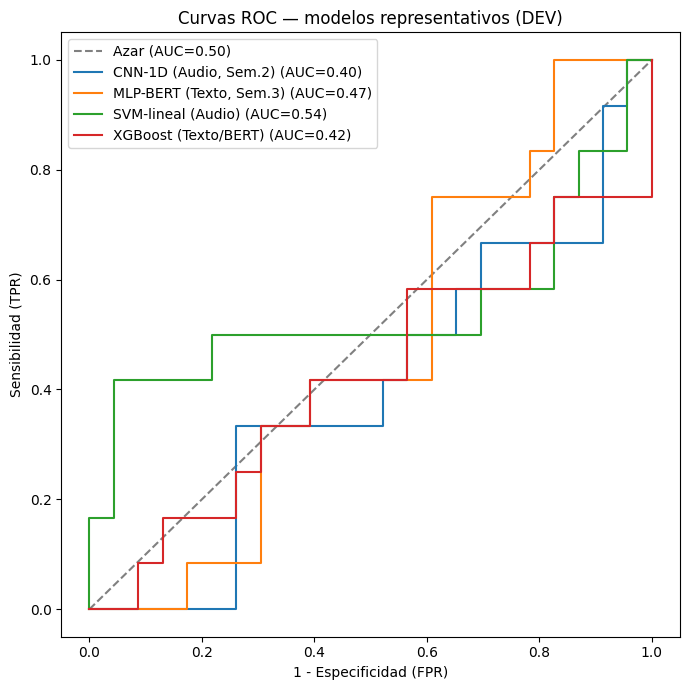

In [16]:
mejor_audio = df_resultados[df_resultados["modelo"].str.contains("Audio")].iloc[0]
mejor_texto = df_resultados[df_resultados["modelo"].str.contains("Texto")].iloc[0]

modelos_para_roc = {r["modelo"]: r for r in results if r["modelo"] in (
    "CNN-1D (Audio, Sem.2)", "MLP-BERT (Texto, Sem.3)",
    mejor_audio["modelo"], mejor_texto["modelo"],
)}

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (AUC=0.50)")

for nombre, r in modelos_para_roc.items():
    y_dv_ref = y_dv_a if "Audio" in nombre else y_dv_t
    fpr, tpr, _ = roc_curve(y_dv_ref, r["_y_prob"])
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={r['auc_roc']:.2f})")

plt.xlabel("1 - Especificidad (FPR)")
plt.ylabel("Sensibilidad (TPR)")
plt.title("Curvas ROC — modelos representativos (DEV)")
plt.legend()
plt.tight_layout()
plt.savefig(BASE_PROYECTO / "week4_roc_curves.png", dpi=200)
plt.show()

## 15. Análisis de errores (FN/FP) del mejor modelo

Se identifican los falsos negativos (depresión no detectada, prioridad clínica de reducción) y los falsos positivos del mejor modelo global de la tabla comparativa. **Advertencia de interpretación:** DEV tiene solo 35 participantes; con 5-8 errores, cualquier patrón demográfico observado puede ser ruido estadístico y debe reportarse con cautela.

In [17]:
mejor_modelo_row = df_resultados.iloc[0]
mejor_modelo_nombre = mejor_modelo_row["modelo"]
es_audio = "Audio" in mejor_modelo_nombre

pids_ref = pids_dv_a if es_audio else pids_dv_t
y_ref = y_dv_a if es_audio else y_dv_t
mejor_result = next(r for r in results if r["modelo"] == mejor_modelo_nombre)

errores_df = pd.DataFrame({
    "Participant_ID": pids_ref,
    "label": y_ref,
    "pred": mejor_result["_y_pred"],
    "prob": mejor_result["_y_prob"],
})

fn_df = errores_df[(errores_df["label"] == 1) & (errores_df["pred"] == 0)]
fp_df = errores_df[(errores_df["label"] == 0) & (errores_df["pred"] == 1)]

print(f"Mejor modelo global: {mejor_modelo_nombre} (F1 macro={mejor_modelo_row['f1_macro']:.3f})")
print(f"Falsos Negativos (FN): {len(fn_df)}")
print(fn_df)
print(f"\nFalsos Positivos (FP): {len(fp_df)}")
print(fp_df)

Mejor modelo global: SVM-lineal (Audio) (F1 macro=0.602)
Falsos Negativos (FN): 7
    Participant_ID  label  pred      prob
3              335    1.0   0.0  0.273211
5              367    1.0   0.0  0.283123
6              377    1.0   0.0  0.291122
10             389    1.0   0.0  0.291549
18             418    1.0   0.0  0.293772
20             422    1.0   0.0  0.288489
23             440    1.0   0.0  0.298199

Falsos Positivos (FP): 5
    Participant_ID  label  pred      prob
11             390    0.0   1.0  0.268189
15             406    0.0   1.0  0.263266
21             436    0.0   1.0  0.261859
24             451    0.0   1.0  0.238483
25             458    0.0   1.0  0.262007


## 16. Concordancia entre modalidades (audio vs. texto)

Se comparan las predicciones del mejor modelo de audio y del mejor modelo de texto **únicamente sobre los participantes de DEV presentes en ambas modalidades** (intersección de `pids_dv_a` y `pids_dv_t`), para evitar comparar conjuntos distintos. Un Cohen's kappa bajo (< 0.40) sugiere que los errores son complementarios entre modalidades, lo cual es una señal favorable para la fusión de la Semana 5.

In [18]:
mejor_audio_result = next(r for r in results if r["modelo"] == mejor_audio["modelo"])
mejor_texto_result = next(r for r in results if r["modelo"] == mejor_texto["modelo"])

df_audio_pred = pd.DataFrame({
    "Participant_ID": pids_dv_a, "label": y_dv_a,
    "pred_audio": mejor_audio_result["_y_pred"],
})
df_texto_pred = pd.DataFrame({
    "Participant_ID": pids_dv_t, "label": y_dv_t,
    "pred_texto": mejor_texto_result["_y_pred"],
})

concordancia_df = df_audio_pred.merge(
    df_texto_pred[["Participant_ID", "pred_texto"]], on="Participant_ID", how="inner"
)

print(f"Participantes comparables (ambas modalidades en DEV): {len(concordancia_df)}")

kappa = cohen_kappa_score(concordancia_df["pred_audio"], concordancia_df["pred_texto"])
agreement = (concordancia_df["pred_audio"] == concordancia_df["pred_texto"]).mean()

fn_audio_ids = set(concordancia_df.loc[
    (concordancia_df["label"] == 1) & (concordancia_df["pred_audio"] == 0), "Participant_ID"])
fn_texto_ids = set(concordancia_df.loc[
    (concordancia_df["label"] == 1) & (concordancia_df["pred_texto"] == 0), "Participant_ID"])

union_fn = fn_audio_ids | fn_texto_ids
complementariedad = len(fn_audio_ids & fn_texto_ids) / len(union_fn) if union_fn else float("nan")

print(f"Acuerdo (agreement): {agreement:.3f}")
print(f"Cohen's kappa       : {kappa:.3f}")
print(f"Complementariedad de FN (baja = buena señal para fusión): {complementariedad:.3f}")

if kappa < 0.40:
    print("\n→ Concordancia baja: los errores de audio y texto parecen complementarios; la fusión tardía simple puede ayudar.")
else:
    print("\n→ Concordancia moderada/alta: considerar fusión temprana o cross-attention en la Semana 5.")

Participantes comparables (ambas modalidades en DEV): 35
Acuerdo (agreement): 0.686
Cohen's kappa       : 0.094
Complementariedad de FN (baja = buena señal para fusión): 0.545

→ Concordancia baja: los errores de audio y texto parecen complementarios; la fusión tardía simple puede ayudar.


## 17. Mapa de errores por participante

Matriz binaria (acierto/error) para cada participante comparable, en los cuatro modelos más informativos (mejor audio, mejor texto, CNN-1D, MLP-BERT). Las columnas completamente en rojo son los "hard cases" del corpus: participantes que ningún modelo clasifica bien.

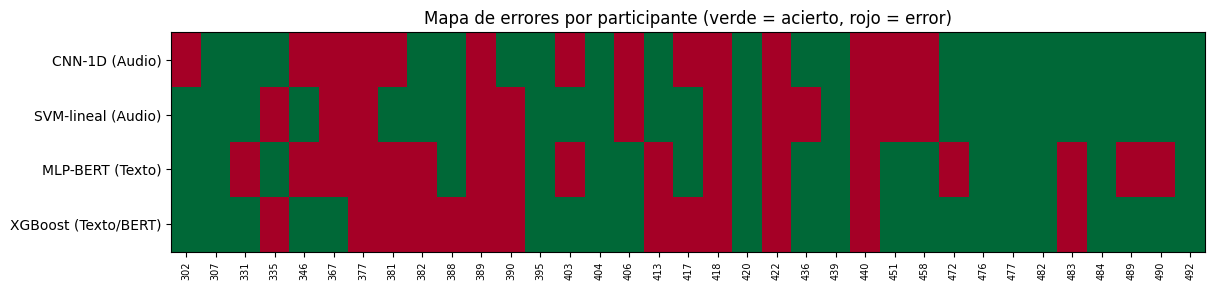

Participantes que fallan en los 4 modelos ('hard cases'): [np.int64(377), np.int64(389), np.int64(418), np.int64(422), np.int64(440)]


In [19]:
modelos_mapa = {
    "CNN-1D (Audio)": (pids_dv_a, y_dv_a, next(r for r in results if r["modelo"] == "CNN-1D (Audio, Sem.2)")["_y_pred"]),
    mejor_audio["modelo"]: (pids_dv_a, y_dv_a, mejor_audio_result["_y_pred"]),
    "MLP-BERT (Texto)": (pids_dv_t, y_dv_t, next(r for r in results if r["modelo"] == "MLP-BERT (Texto, Sem.3)")["_y_pred"]),
    mejor_texto["modelo"]: (pids_dv_t, y_dv_t, mejor_texto_result["_y_pred"]),
}

pids_comunes = sorted(set(pids_dv_a) & set(pids_dv_t))

matriz_aciertos = []
for nombre, (pids_m, y_m, pred_m) in modelos_mapa.items():
    serie = pd.Series(pred_m, index=pids_m)
    labels_serie = pd.Series(y_m, index=pids_m)
    fila = [(int(serie[pid] == labels_serie[pid])) for pid in pids_comunes]
    matriz_aciertos.append(fila)

matriz_aciertos = np.array(matriz_aciertos)  # 1 = acierto, 0 = error

fig, ax = plt.subplots(figsize=(max(8, len(pids_comunes) * 0.35), 3))
ax.imshow(matriz_aciertos, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax.set_yticks(range(len(modelos_mapa)))
ax.set_yticklabels(list(modelos_mapa.keys()))
ax.set_xticks(range(len(pids_comunes)))
ax.set_xticklabels(pids_comunes, rotation=90, fontsize=7)
ax.set_title("Mapa de errores por participante (verde = acierto, rojo = error)")
plt.tight_layout()
plt.savefig(BASE_PROYECTO / "week4_error_map.png", dpi=200)
plt.show()

hard_cases = [pid for i, pid in enumerate(pids_comunes) if matriz_aciertos[:, i].sum() == 0]
print("Participantes que fallan en los 4 modelos ('hard cases'):", hard_cases)

## 18. Visualización t-SNE de los embeddings (audio y texto)

Se proyectan a 2D los embeddings de DEV para cada modalidad. `perplexity` se ajusta al tamaño de la muestra (recomendación del material: 10-30 para conjuntos pequeños como DEV).

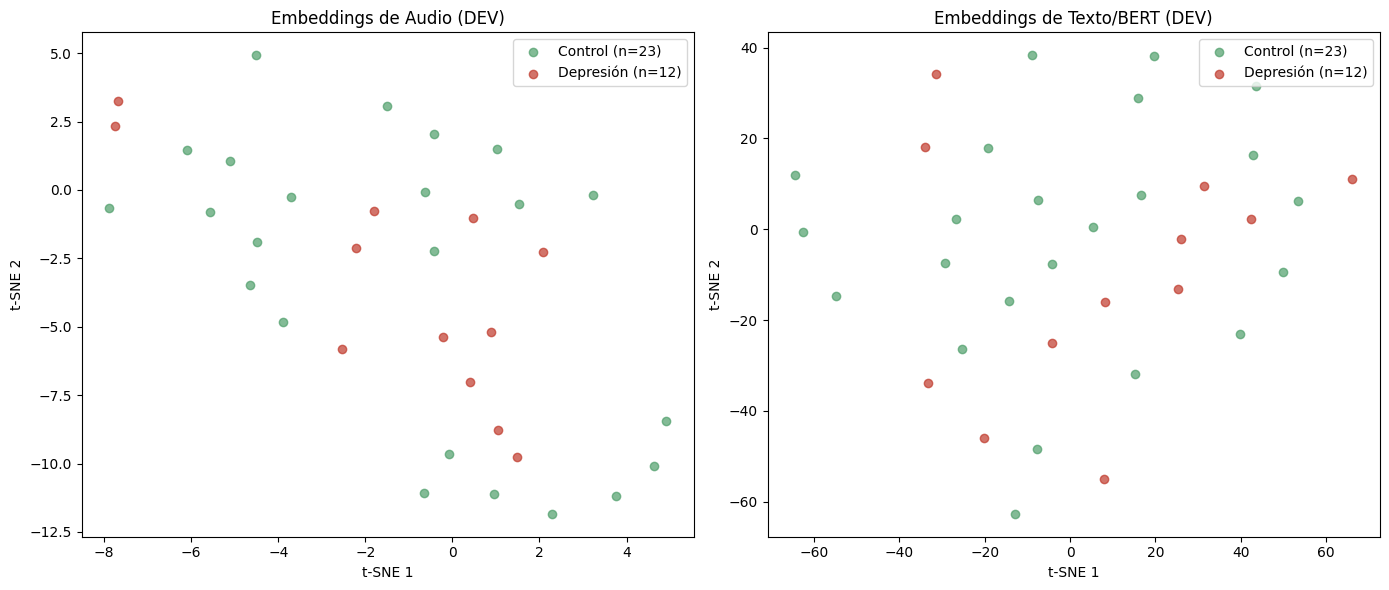

In [20]:
def plot_tsne(X, y, ax, title):
    perplexity = min(30, max(5, len(X) // 3))
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=SEED, init="pca")
    emb2d = tsne.fit_transform(X)

    for clase, color, etiqueta in [(0, "#4E9E6A", "Control"), (1, "#C0392B", "Depresión")]:
        mask = y == clase
        ax.scatter(emb2d[mask, 0], emb2d[mask, 1], c=color, label=f"{etiqueta} (n={mask.sum()})", alpha=0.7)

    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_tsne(X_dv_a, y_dv_a, axes[0], "Embeddings de Audio (DEV)")
plot_tsne(X_dv_t, y_dv_t, axes[1], "Embeddings de Texto/BERT (DEV)")
plt.tight_layout()
plt.savefig(BASE_PROYECTO / "week4_tsne.png", dpi=200)
plt.show()

## 19. Ablación de features de audio

Se entrena un SVM-RBF sobre subconjuntos de los grupos de características de audio definidos en `feature_names()` de la Semana 2 (MFCC, Delta, Delta-Delta, Chroma, Mel, ZCR, RMS), para medir cuánto aporta cada familia de features. Reutiliza `X_train_audio`/`X_dev_audio` ya escalados; no se recalculan los MFCC.

                              subset  f1_macro
Todo (MFCC+Delta+Chroma+Mel+ZCR+RMS)  0.370000
                       MFCC + Deltas  0.403409
                           Solo MFCC  0.440000


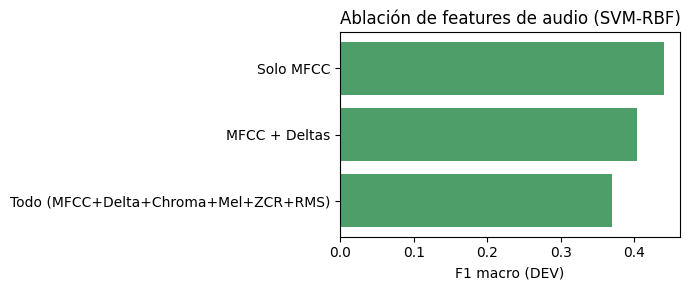

In [21]:
N_MFCC, N_MELS = 13, 40
GROUPS = [("mfcc", N_MFCC), ("delta", N_MFCC), ("delta2", N_MFCC),
          ("chroma", 12), ("mel", N_MELS), ("zcr", 1), ("rms", 1)]

# Los primeros len(GROUPS) bloques son las medias; los siguientes, las desviaciones estándar
n_stats_features = sum(size for _, size in GROUPS)
offsets_mean, offsets_std, cursor = {}, {}, 0
for name, size in GROUPS:
    offsets_mean[name] = list(range(cursor, cursor + size))
    cursor += size
for name, size in GROUPS:
    offsets_std[name] = list(range(cursor, cursor + size))
    cursor += size


def idx_for(*names):
    idx = []
    for name in names:
        idx += offsets_mean[name] + offsets_std[name]
    return idx


subsets_audio = {
    "Solo MFCC": idx_for("mfcc"),
    "MFCC + Deltas": idx_for("mfcc", "delta", "delta2"),
    "Todo (MFCC+Delta+Chroma+Mel+ZCR+RMS)": list(range(X_tr_a.shape[1])),
}

ablacion_audio = []
for nombre, idx in subsets_audio.items():
    svc = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", random_state=SEED)
    svc.fit(X_tr_a[:, idx], y_tr_a)
    f1 = f1_score(y_dv_a, svc.predict(X_dv_a[:, idx]), average="macro")
    ablacion_audio.append({"subset": nombre, "f1_macro": f1})

df_ablacion_audio = pd.DataFrame(ablacion_audio).sort_values("f1_macro")
print(df_ablacion_audio.to_string(index=False))

plt.figure(figsize=(7, 3))
plt.barh(df_ablacion_audio["subset"], df_ablacion_audio["f1_macro"], color="#4E9E6A")
plt.xlabel("F1 macro (DEV)")
plt.title("Ablación de features de audio (SVM-RBF)")
plt.tight_layout()
plt.savefig(BASE_PROYECTO / "week4_ablacion_audio.png", dpi=200)
plt.show()

## 20. Nota sobre ablación de texto (limitación declarada)

El material de la semana sugiere comparar además `mean pooling` vs. `[CLS]`, BERT vs. MentalBERT, y BERT + features léxicas. La auditoría de la Semana 3 detectó que **solo se generaron embeddings `[CLS]` de `bert-base-uncased`**; no existen en disco embeddings de `mean pooling`, de MentalBERT, ni features léxicas independientes. Generar esos artefactos ahora implicaría recalcular embeddings en la Semana 4, violando el principio metodológico de esta semana (reutilizar, no recalcular).

**Recomendación:** si se desea esta comparación completa, debe hacerse como una extensión explícita de la Semana 3 (generando y guardando esos artefactos allí, con sus propias validaciones TRAIN/DEV/TEST) y solo entonces traerlos aquí para comparar. Por ahora, la ablación de texto se deja fuera de este notebook para no reportar resultados basados en datos que no fueron generados con el mismo rigor metodológico que el resto del proyecto.

## 21. SHAP sobre el mejor modelo basado en árboles

SHAP (`TreeExplainer`) requiere un modelo de árboles (Random Forest o XGBoost); no aplica directamente a SVM ni a las redes de PyTorch. Se elige automáticamente el mejor modelo basado en árboles según F1 macro en DEV, y se aplica sobre los 768 embeddings de BERT (no existen features léxicas independientes, ver sección 20).

Mejor modelo basado en árboles: XGBoost (Texto/BERT)


/tmp/ipykernel_991/332698639.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


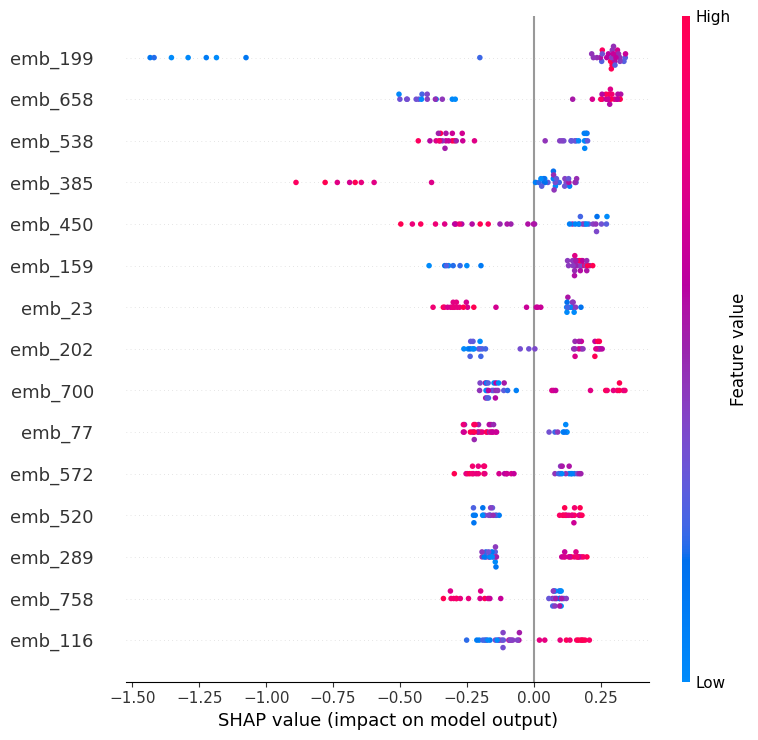

In [22]:
modelos_arbol = {
    "Random Forest (Audio)": (rf_audio, X_dv_a, "audio"),
    "Random Forest (Texto/BERT)": (rf_text, X_dv_t, "text"),
    "XGBoost (Audio)": (xgb_audio, X_dv_a, "audio"),
    "XGBoost (Texto/BERT)": (xgb_text, X_dv_t, "text"),
}

nombre_mejor_arbol = df_resultados[df_resultados["modelo"].isin(modelos_arbol.keys())].iloc[0]["modelo"]
modelo_shap, X_dv_shap, modalidad_shap = modelos_arbol[nombre_mejor_arbol]

feature_names_shap = (
    [f"emb_{i}" for i in range(X_dv_shap.shape[1])] if modalidad_shap == "text"
    else [f"audio_{i}" for i in range(X_dv_shap.shape[1])]
)

print(f"Mejor modelo basado en árboles: {nombre_mejor_arbol}")

explainer = shap.TreeExplainer(modelo_shap)
shap_values = explainer.shap_values(X_dv_shap)

shap.summary_plot(
    shap_values, X_dv_shap, feature_names=feature_names_shap,
    max_display=15, show=False,
)
plt.tight_layout()
plt.savefig(BASE_PROYECTO / "week4_shap_summary.png", dpi=200, bbox_inches="tight")
plt.show()

## 22. Guardar productos de la Semana 4

Se guardan la tabla comparativa, los modelos entrenados (SVM, Random Forest, XGBoost) y las figuras generadas. Los modelos de PyTorch (CNN-1D, MLP-BERT) no se vuelven a guardar aquí: siguen siendo los de las Semanas 2 y 3, solo se reutilizaron para inferencia.

In [24]:
# ============================================================
# GUARDAR TODOS LOS PRODUCTOS DE LA SEMANA 4
# ============================================================

import json as _json
import numpy as np
import joblib

# ------------------------------------------------------------
# Función para convertir tipos de NumPy a tipos nativos Python
# ------------------------------------------------------------
def to_python(obj):

    if isinstance(obj, dict):
        return {k: to_python(v) for k, v in obj.items()}

    elif isinstance(obj, list):
        return [to_python(v) for v in obj]

    elif isinstance(obj, tuple):
        return tuple(to_python(v) for v in obj)

    elif isinstance(obj, np.integer):
        return int(obj)

    elif isinstance(obj, np.floating):
        return float(obj)

    elif isinstance(obj, np.bool_):
        return bool(obj)

    elif isinstance(obj, np.ndarray):
        return obj.tolist()

    else:
        return obj


# ------------------------------------------------------------
# Tabla comparativa
# ------------------------------------------------------------
df_resultados_export = df_resultados.drop(
    columns=[c for c in df_resultados.columns if c.startswith("_")],
    errors="ignore"
)

df_resultados_export.to_csv(
    BASE_PROYECTO / "week4_model_comparison.csv",
    index=False
)


# ------------------------------------------------------------
# Guardar modelos entrenados
# ------------------------------------------------------------
joblib.dump(
    svm_lineal_audio.best_estimator_,
    BASE_PROYECTO / "svm_linear_audio.pkl"
)

joblib.dump(
    svm_rbf_audio.best_estimator_,
    BASE_PROYECTO / "svm_rbf_audio.pkl"
)

joblib.dump(
    svm_rbf_text.best_estimator_,
    BASE_PROYECTO / "svm_rbf_text.pkl"
)

joblib.dump(
    rf_audio,
    BASE_PROYECTO / "rf_audio.pkl"
)

joblib.dump(
    rf_text,
    BASE_PROYECTO / "rf_text.pkl"
)

joblib.dump(
    xgb_audio,
    BASE_PROYECTO / "xgb_audio.pkl"
)

joblib.dump(
    xgb_text,
    BASE_PROYECTO / "xgb_text.pkl"
)


# ------------------------------------------------------------
# Guardar errores y concordancia
# ------------------------------------------------------------
errores_df.to_csv(
    BASE_PROYECTO / "week4_errores_mejor_modelo.csv",
    index=False
)

concordancia_df.to_csv(
    BASE_PROYECTO / "week4_concordancia_audio_texto.csv",
    index=False
)


# ------------------------------------------------------------
# Métricas generales
# ------------------------------------------------------------
metrics_week4 = {

    "mejor_modelo_global": str(mejor_modelo_nombre),

    "mejor_modelo_audio": str(mejor_audio["modelo"]),

    "mejor_modelo_texto": str(mejor_texto["modelo"]),

    "kappa_audio_texto": float(kappa),

    "agreement_audio_texto": float(agreement),

    "complementariedad_fn": float(complementariedad),

    "hard_cases": to_python(hard_cases),

    "n_modelos_comparados": int(len(df_resultados_export))

}


# ------------------------------------------------------------
# Guardar JSON
# ------------------------------------------------------------
with open(
    BASE_PROYECTO / "text_week4_metrics.json",
    "w",
    encoding="utf-8"
) as f:

    _json.dump(
        to_python(metrics_week4),
        f,
        indent=2,
        ensure_ascii=False
    )


print("=" * 60)
print("✓ Todos los productos de la Semana 4 fueron guardados.")
print("Carpeta:", BASE_PROYECTO)
print("=" * 60)

✓ Todos los productos de la Semana 4 fueron guardados.
Carpeta: /content/drive/MyDrive/Colab Notebooks/Programa Delphin


## 23. Verificación de los archivos generados

In [25]:
archivos_esperados = [
    "week4_model_comparison.csv",
    "week4_errores_mejor_modelo.csv",
    "week4_concordancia_audio_texto.csv",
    "week4_roc_curves.png",
    "week4_error_map.png",
    "week4_tsne.png",
    "week4_ablacion_audio.png",
    "week4_shap_summary.png",
    "svm_linear_audio.pkl", "svm_rbf_audio.pkl", "svm_rbf_text.pkl",
    "rf_audio.pkl", "rf_text.pkl", "xgb_audio.pkl", "xgb_text.pkl",
]

print("="*60)
print("VERIFICACIÓN DE LOS ARCHIVOS GENERADOS")
print("="*60)

faltantes_archivos = [a for a in archivos_esperados if not (BASE_PROYECTO / a).exists()]
for a in archivos_esperados:
    existe = (BASE_PROYECTO / a).exists()
    print(f"[{'OK' if existe else 'FALTA'}] {a}")

assert not faltantes_archivos, f"Archivos faltantes: {faltantes_archivos}"

df_check = pd.read_csv(BASE_PROYECTO / "week4_model_comparison.csv")
assert len(df_check) >= 8, "La tabla comparativa guardada tiene menos de 8 modelos."
print(f"\n✓ Todos los archivos existen. Tabla comparativa con {len(df_check)} modelos.")

VERIFICACIÓN DE LOS ARCHIVOS GENERADOS
[OK] week4_model_comparison.csv
[OK] week4_errores_mejor_modelo.csv
[OK] week4_concordancia_audio_texto.csv
[OK] week4_roc_curves.png
[OK] week4_error_map.png
[OK] week4_tsne.png
[OK] week4_ablacion_audio.png
[OK] week4_shap_summary.png
[OK] svm_linear_audio.pkl
[OK] svm_rbf_audio.pkl
[OK] svm_rbf_text.pkl
[OK] rf_audio.pkl
[OK] rf_text.pkl
[OK] xgb_audio.pkl
[OK] xgb_text.pkl

✓ Todos los archivos existen. Tabla comparativa con 9 modelos.


## 24. Verificación de integridad del dataset y de los resultados

In [26]:
print("="*60)
print("VERIFICACIÓN DE INTEGRIDAD")
print("="*60)

# Ningún modelo debe faltar métricas ni tener valores fuera de rango
assert df_check[["f1_macro", "auc_roc", "sensibilidad", "especificidad"]].isna().sum().sum() == 0, \
    "Hay métricas faltantes (NaN) en la tabla comparativa."
assert df_check["f1_macro"].between(0, 1).all(), "F1 macro fuera de rango [0,1]."
assert df_check["auc_roc"].between(0, 1).all(), "AUC-ROC fuera de rango [0,1]."

# Las matrices de confusión deben sumar el tamaño de DEV correspondiente
for _, row in df_check.iterrows():
    total = row["tp"] + row["fp"] + row["fn"] + row["tn"]
    esperado = len(y_dv_a) if "Audio" in row["modelo"] else len(y_dv_t)
    assert total == esperado, f"La matriz de confusión de {row['modelo']} no suma el tamaño de DEV."

print("✓ No hay métricas faltantes ni fuera de rango.")
print("✓ Las matrices de confusión de todos los modelos son consistentes con el tamaño de DEV.")
print(f"✓ {len(concordancia_df)} participantes usados en el análisis de concordancia (intersección audio∩texto en DEV).")

VERIFICACIÓN DE INTEGRIDAD
✓ No hay métricas faltantes ni fuera de rango.
✓ Las matrices de confusión de todos los modelos son consistentes con el tamaño de DEV.
✓ 35 participantes usados en el análisis de concordancia (intersección audio∩texto en DEV).


## 25. Validación metodológica (TRAIN / DEV / TEST)

In [27]:
print("="*60)
print("VALIDACIÓN METODOLÓGICA — SEMANA 4")
print("="*60)

# Re-verificación final de aislamiento de TEST/FULL_TEST
assert ids_train_audio.isdisjoint(ids_dev_audio), "TRAIN y DEV de audio se solapan."
assert ids_train_text.isdisjoint(ids_dev_text), "TRAIN y DEV de texto se solapan."
assert (ids_train_audio | ids_dev_audio).isdisjoint(ids_test_off), \
    "El conjunto TEST oficial fue usado en audio."
assert (ids_train_text | ids_dev_text).isdisjoint(ids_test_off), \
    "El conjunto TEST oficial fue usado en texto."

print("Participantes también presentes en FULL_TEST (informativo, no se usaron):",
      len((ids_train_audio | ids_dev_audio) & ids_full_test_off))

print(f"Participantes TRAIN (audio) : {len(ids_train_audio)}")
print(f"Participantes DEV (audio)   : {len(ids_dev_audio)}")
print(f"Participantes TRAIN (texto) : {len(ids_train_text)}")
print(f"Participantes DEV (texto)   : {len(ids_dev_text)}")
print(f"Participantes TEST (oficial): {len(ids_test_off)}")

print("\n✓ Todos los modelos de esta semana se ajustaron únicamente con TRAIN.")
print("✓ Todas las métricas reportadas se calcularon únicamente sobre DEV.")
print("✓ TEST y FULL_TEST no intervinieron en ninguna etapa (ajuste, búsqueda de hiperparámetros o evaluación).")
print("✓ No existe data leakage.")
print("\n" + "="*60)
print("SEMANA 4 FINALIZADA - LISTA PARA LA SEMANA 5 (FUSIÓN MULTIMODAL)")
print("="*60)

VALIDACIÓN METODOLÓGICA — SEMANA 4
Participantes también presentes en FULL_TEST (informativo, no se usaron): 0
Participantes TRAIN (audio) : 107
Participantes DEV (audio)   : 35
Participantes TRAIN (texto) : 107
Participantes DEV (texto)   : 35
Participantes TEST (oficial): 47

✓ Todos los modelos de esta semana se ajustaron únicamente con TRAIN.
✓ Todas las métricas reportadas se calcularon únicamente sobre DEV.
✓ TEST y FULL_TEST no intervinieron en ninguna etapa (ajuste, búsqueda de hiperparámetros o evaluación).
✓ No existe data leakage.

SEMANA 4 FINALIZADA - LISTA PARA LA SEMANA 5 (FUSIÓN MULTIMODAL)


## 26. Discusión clínica y limitaciones (completar con los resultados obtenidos)

Esta sección es una **plantilla guiada**: los valores concretos de F1/AUC no se conocen hasta ejecutar el notebook con los datos reales de Drive, por lo que no se fijan aquí números de antemano (evitar reportar cifras no verificadas). Al ejecutar, completar con los valores de `df_resultados`.

**Preguntas a responder con los resultados de `df_resultados` y `concordancia_df`:**
1. ¿Los clasificadores clásicos (SVM/RF/XGBoost) sobre embeddings BERT igualan o superan al MLP de la Semana 3? Si XGBoost-texto supera al MLP por más de 0.03 de F1 macro, considerar usar XGBoost como componente de texto en la fusión de la Semana 5.
2. ¿Algún clasificador clásico sobre embeddings de audio supera al CNN-1D de la Semana 2 por más de 0.05 de F1 macro? Si es así, los embeddings de audio (58 dims agregadas) parecen mejores features que alimentar a la fusión que las secuencias crudas de MFCC.
3. ¿Qué dice el valor de Cohen's kappa (sección 16) sobre el tipo de fusión a usar en la Semana 5? (< 0.40 → fusión tardía simple probablemente ya ayuda; ≥ 0.60 → considerar fusión temprana o cross-attention).
4. ¿Los "hard cases" identificados en el mapa de errores (sección 17) tienen algo en común? Dado que DEV tiene solo 35 participantes, cualquier patrón demográfico debe reportarse como hipótesis a validar, no como conclusión firme.
5. ¿Qué muestra el SHAP summary plot sobre las dimensiones del embedding BERT más influyentes? A diferencia de features léxicas interpretables (ratio de primera persona, negatividad, etc., no disponibles en este proyecto — ver sección 20), las dimensiones de BERT no tienen un significado semántico directo; el valor de este SHAP es principalmente diagnóstico (¿el modelo depende de pocas dimensiones o de muchas?), no clínico-interpretativo.

**Limitaciones metodológicas heredadas (declarar en el reporte):**
- Tamaño del corpus: 142 participantes totales (107 TRAIN, 35 DEV); alta varianza estadística en las métricas de DEV.
- El TEST set oficial no tiene etiquetas públicas; todas las métricas reportadas son sobre DEV.
- Sesgo demográfico del corpus DAIC-WOZ (población de Los Ángeles, 2013).
- Truncamiento de texto a 512 tokens (Semana 3): se pierde información de las entrevistas más largas.
- PHQ-8 es una escala de autoinforme, no un diagnóstico clínico estructurado.
- No se generaron variantes de embeddings de texto (mean pooling, MentalBERT, features léxicas) por respetar el principio de no recalcular en la Semana 4 (ver sección 20); esto limita el alcance de la ablación de texto respecto a lo sugerido en el material de la semana.